In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
import os 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
TRUE_NEWS_PATH = "data/True.csv"
FAKE_NEWS_PATH = "data/Fake.csv"
OUTPUT_DIR = "data"

In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

true_news = pd.read_csv(TRUE_NEWS_PATH)
fake_news = pd.read_csv(FAKE_NEWS_PATH)
    
print(f"True news articles: {len(true_news)}")
print(f"Fake news articles: {len(fake_news)}")

True news articles: 21417
Fake news articles: 23481


In [4]:
true_news.columns
fake_news.columns
true_news.duplicated().sum()
fake_news.duplicated().sum()
true_news = true_news.drop_duplicates()
fake_news = fake_news.drop_duplicates()
true_news.isnull().sum()
fake_news.isnull().sum()
true_news.info()
fake_news.info()


<class 'pandas.DataFrame'>
Index: 21211 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21211 non-null  str  
 1   text     21211 non-null  str  
 2   subject  21211 non-null  str  
 3   date     21211 non-null  str  
dtypes: str(4)
memory usage: 51.1 MB
<class 'pandas.DataFrame'>
Index: 23478 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23478 non-null  str  
 1   text     23478 non-null  str  
 2   subject  23478 non-null  str  
 3   date     23478 non-null  str  
dtypes: str(4)
memory usage: 60.6 MB


In [5]:
true_news['label'] = 1
fake_news['label'] = 0


In [6]:
combined_data = pd.concat([true_news, fake_news], ignore_index=True)

print(f"\nTotal articles: {len(combined_data)}")
print(f"\nDataset columns: {combined_data.columns.tolist()}")
print(f"\nFirst few rows:\n{combined_data.head()}")


Total articles: 44689

Dataset columns: ['title', 'text', 'subject', 'date', 'label']

First few rows:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30

In [7]:
import re

def remove_urls(text):
    return re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', text, flags=re.MULTILINE)

def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"
                               u"\U0001F300-\U0001F5FF"
                               u"\U0001F680-\U0001F6FF"
                               u"\U0001F1E0-\U0001F1FF"
                               "]+", flags=re.UNICODE)
    return re.sub(emoji_pattern, '', text)

combined_data['title'] = combined_data['title'].apply(remove_urls).apply(remove_emojis).str.strip()
combined_data['text'] = combined_data['text'].apply(remove_urls).apply(remove_emojis).str.strip()

combined_data = combined_data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Cleaning done. First few rows after shuffle:")
print(combined_data['label'].head(10).tolist())

Cleaning done. First few rows after shuffle:
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0]


C:\Users\juliu\AppData\Local\Temp\ipykernel_15180\3425844237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=combined_data, x='label', palette='pastel', edgecolor='black')


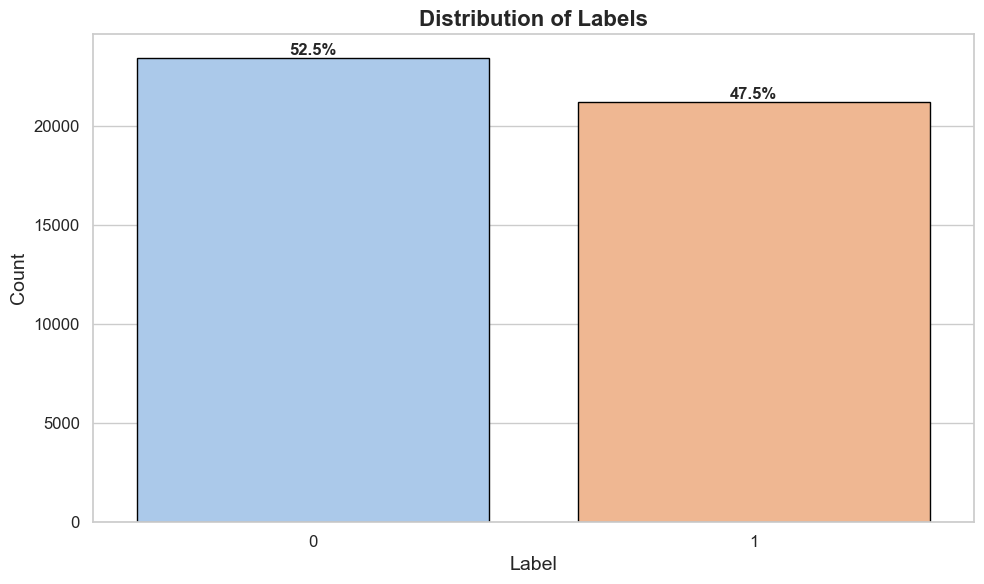

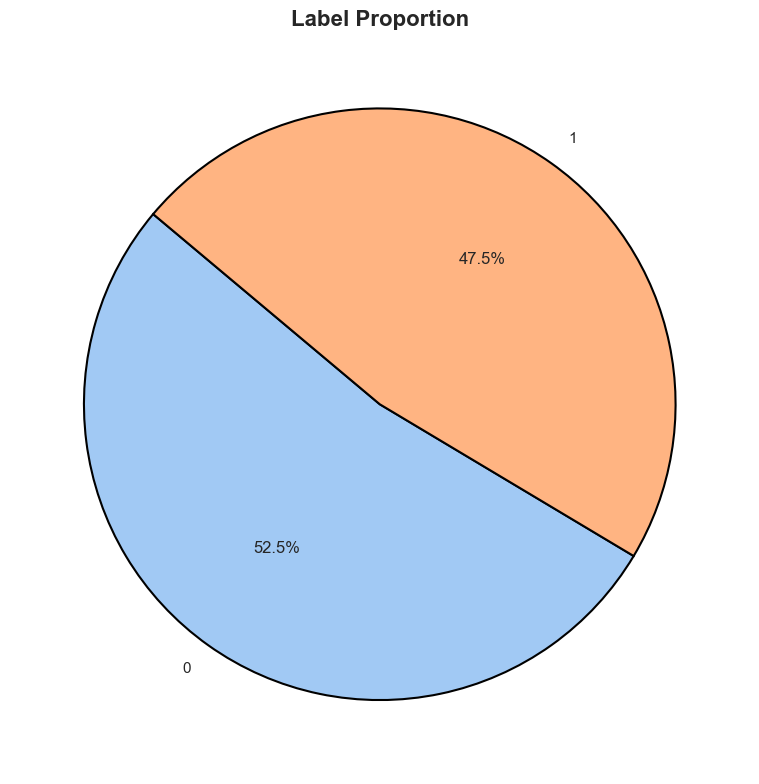

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
ax = sns.countplot(data=combined_data, x='label', palette='pastel', edgecolor='black')

total = len(combined_data)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count/total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Labels', fontsize=16, fontweight='bold')
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')
label_counts = combined_data['label'].value_counts()
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
plt.title('Label Proportion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
combined_data['subject'].unique()

<ArrowStringArray>
[      'worldnews',       'left-news',        'politics',            'News',
    'politicsNews',     'Middle-east', 'Government News',         'US_News']
Length: 8, dtype: str

In [10]:
combined_data['subject'].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

=== WORD COUNT STATS PER LABEL ===
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      23478.0  437.8  408.5  2.0  254.0  378.0  521.0  8148.0
1      21211.0  394.7  273.8  4.0  157.0  368.0  533.0  5181.0


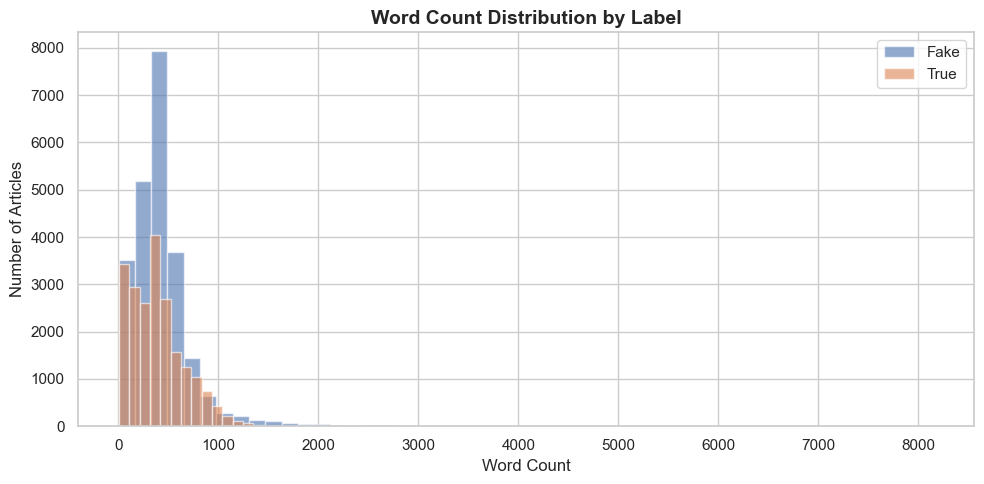


=== SAMPLE FAKE NEWS ===
Title: Trump Just Got DESTROYED By One Of America’s Most Respected Journalists (VIDEO/IMAGE)
Text: One of America s most legendary journalists, Dan Rather, used his gift with words for a very special purpose on Wednesday: to blast Donald Trump and rally the press against the dangerous candidate.In ...

Title: CHAMPION OF FOREIGN WORKERS: Hillary Gets Standing Ovation In India…”There’s No Way To Legislate Against Outsourcing” [VIDEO]
Text: Every union member who believes the Democrats are looking out for them needs to remember, that President Bill Clinton signed the NAFTA agreement and Hillary defended the outsourcing of American jobs L...

=== SAMPLE TRUE NEWS ===
Title: Saudi aims to issue tourist visas next year, official says
Text: DUBAI (Reuters) - Saudi Arabia aims to start issuing tourist visas to foreigners next year, a senior Saudi official told CNN, as the government seeks to open up the conservative kingdom and find new s...

Title: Syrian opposition

In [11]:
# 1. Text length distribution per label
combined_data['text_length'] = combined_data['title'].str.split().str.len() + combined_data['text'].str.split().str.len()

print("=== WORD COUNT STATS PER LABEL ===")
print(combined_data.groupby('label')['text_length'].describe().round(1))

plt.figure(figsize=(10, 5))
for label, name in [(0, 'Fake'), (1, 'True')]:
    subset = combined_data[combined_data['label'] == label]['text_length']
    plt.hist(subset, bins=50, alpha=0.6, label=name)
plt.title('Word Count Distribution by Label', fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Sample articles from each class
print("\n=== SAMPLE FAKE NEWS ===")
fake_sample = combined_data[combined_data['label'] == 0][['title', 'text']].sample(2, random_state=42)
for _, row in fake_sample.iterrows():
    print(f"Title: {row['title']}")
    print(f"Text: {row['text'][:200]}...")
    print()

print("=== SAMPLE TRUE NEWS ===")
true_sample = combined_data[combined_data['label'] == 1][['title', 'text']].sample(2, random_state=42)
for _, row in true_sample.iterrows():
    print(f"Title: {row['title']}")
    print(f"Text: {row['text'][:200]}...")
    print()

C:\Users\juliu\AppData\Local\Temp\ipykernel_15180\1118234142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=combined_data, x='subject', palette='pastel', edgecolor='black')


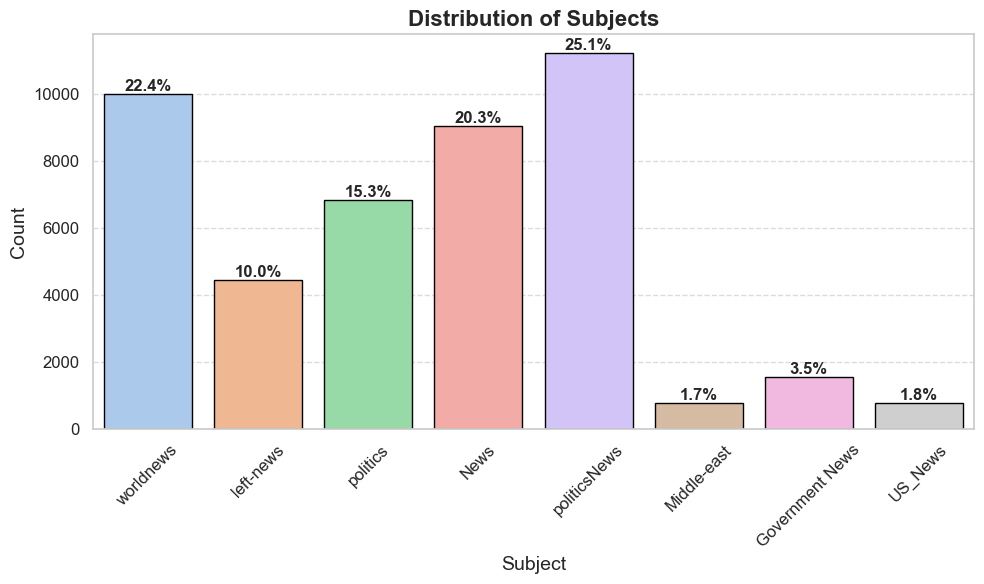

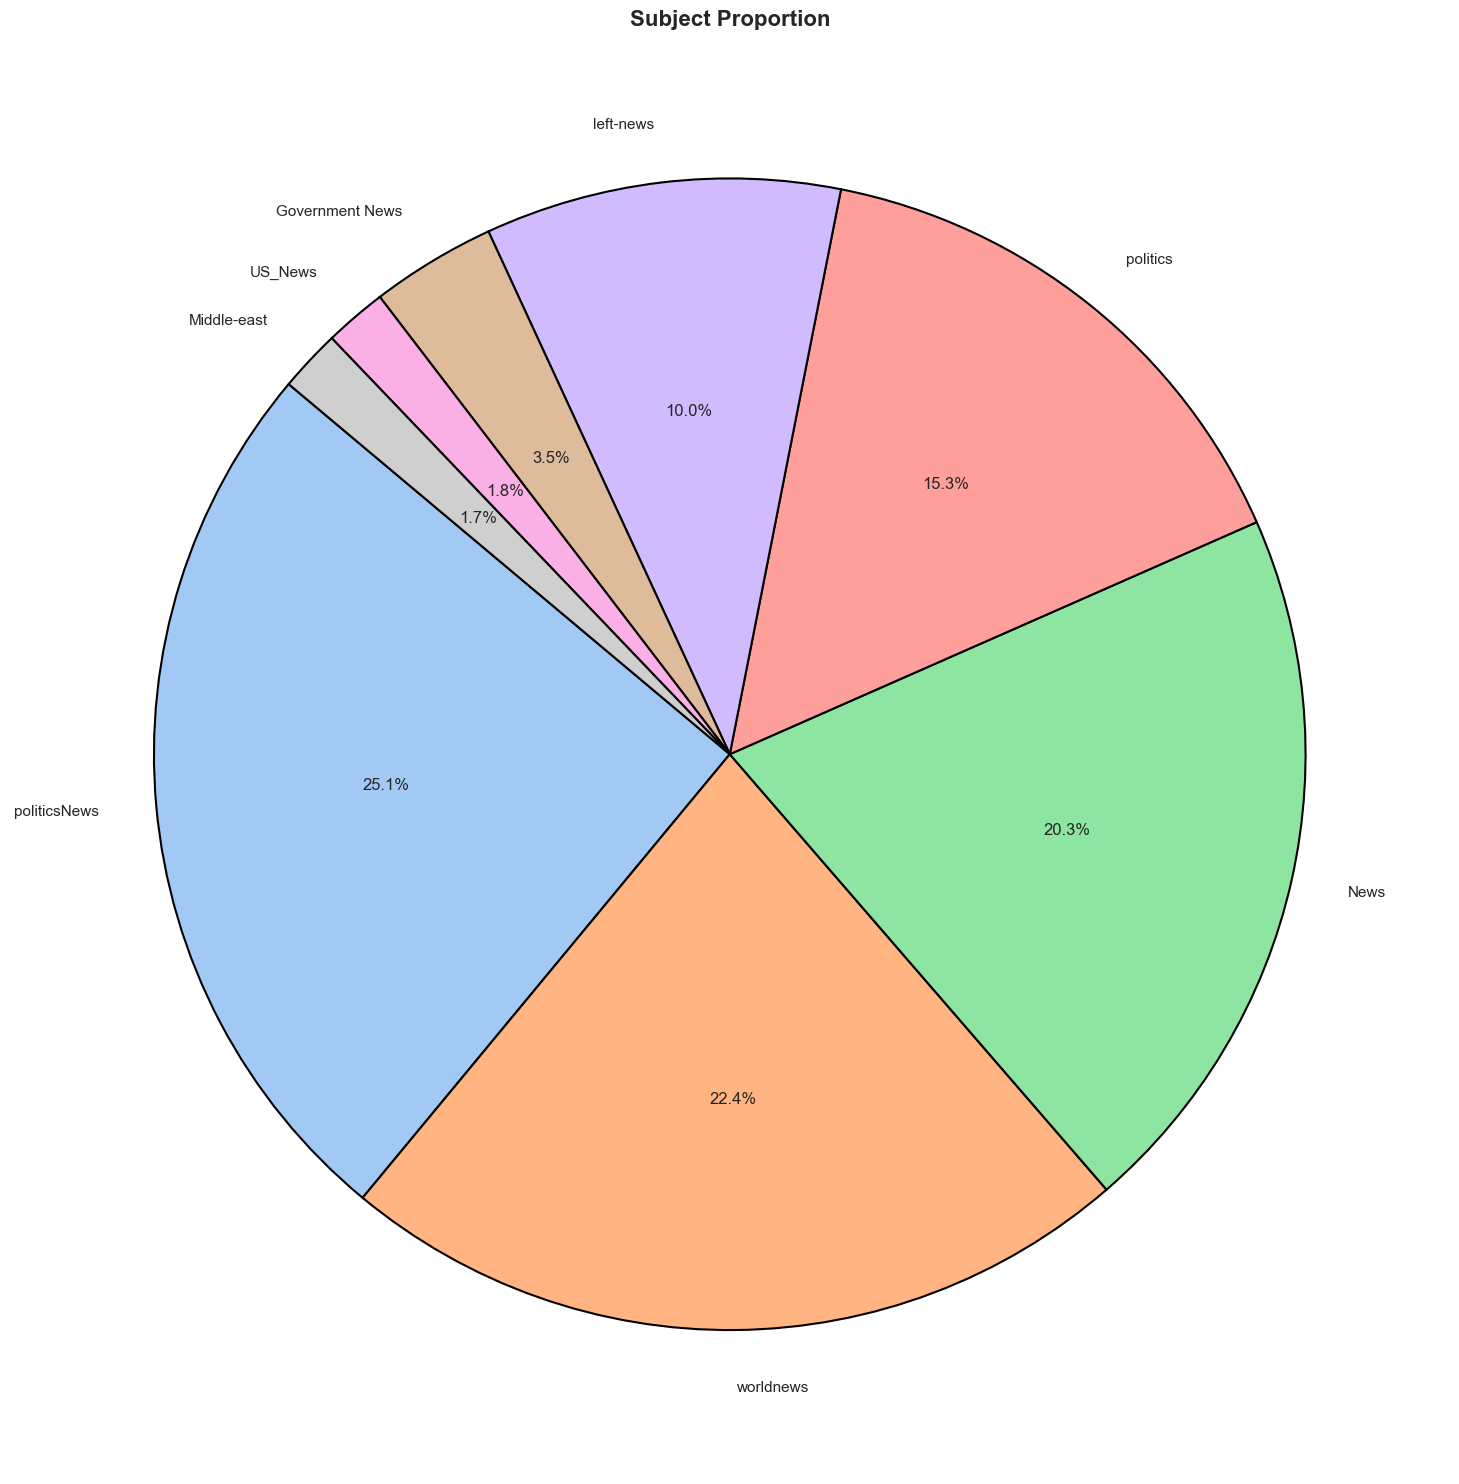

In [12]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=combined_data, x='subject', palette='pastel', edgecolor='black')

total = len(combined_data)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Subjects', fontsize=16, fontweight='bold')
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 15))
colors = sns.color_palette('pastel')
subject_counts = combined_data['subject'].value_counts()

plt.pie(subject_counts, labels=subject_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
plt.title('Subject Proportion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
test_size = 0.2
random_state = 42

train_data, test_data = train_test_split(
    combined_data,
    test_size=test_size,
    random_state=random_state,
    stratify=combined_data['label']
)

print(f"Training set size: {len(train_data)} ({len(train_data)/len(combined_data)*100:.1f}%)")
print(f"Test set size: {len(test_data)} ({len(test_data)/len(combined_data)*100:.1f}%)")

print(f"\nTraining set label distribution:")
print(train_data['label'].value_counts())
print(f"\nTest set label distribution:")
print(test_data['label'].value_counts())

Training set size: 35751 (80.0%)
Test set size: 8938 (20.0%)

Training set label distribution:
label
0    18782
1    16969
Name: count, dtype: int64

Test set label distribution:
label
0    4696
1    4242
Name: count, dtype: int64


In [14]:
train_path = os.path.join(OUTPUT_DIR, "train.csv")
test_path = os.path.join(OUTPUT_DIR, "test.csv")
    
print(f"\nSaving datasets...")
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)
    
print(f"✓ Training data saved to: {train_path}")
print(f"✓ Test data saved to: {test_path}")


Saving datasets...
✓ Training data saved to: data\train.csv
✓ Test data saved to: data\test.csv
